# Train Baseline #1 — Xception trên cache FF++ C23 đã crop

**Input:** cache ảnh khuôn mặt đã crop từ notebook `Prepare_FFpp_C23_Cache` (dataset Kaggle
bạn đã tạo từ output của notebook đó — cấu trúc `{split}/{real|fake_METHOD}/{video_id}/frame_XX.jpg`
+ file `manifest_processed.csv`).

**Baseline này:**
- Kiến trúc: Xception (timm), phân loại **theo từng khung hình** (frame-level) — đúng cách bài
  gốc FaceForensics++ (Rössler et al., 2019) huấn luyện Xception
- Cùng tập train/val/test, cùng cache dữ liệu sẽ được tái sử dụng cho SBI/UCF/Wu et al./mô hình đề xuất
- Đánh giá: **Accuracy, AUC, EER** (EER tự tính, không lấy từ paper nào)

**Trước khi chạy:**
1. Settings → Accelerator → GPU
2. Add Input → dataset cache bạn đã tạo (ví dụ `ffpp-c23-face-cache`) → sửa `CACHE_DIR` ở Mục 1
   cho khớp đúng đường dẫn thực tế trong `/kaggle/input/...`

---

### ⚠️ Minh bạch: notebook này KHÔNG phải bản sao 100% bài báo gốc

| Thành phần | Bài báo gốc (Rössler et al., 2019) | Notebook này | |
|---|---|---|---|
| Backbone + margin crop 1.3× | Xception, pretrained ImageNet | Giống | ✅ |
| Optimizer | Adam, LR=0.0002 | Adam, LR=0.0002, không weight decay, không scheduler | ✅ |
| Đầu classifier | Thay thẳng FC cuối | Thêm Linear(256)+ReLU+Dropout | ⚠️ khác |
| Lấy frame để train | 270 frame/video cố định, train phẳng | Lấy ngẫu nhiên 4 frame/video mỗi epoch | ⚠️ khác |
| **Cách đánh giá** | Accuracy theo **frame** | Gộp theo **video** (average pooling) | ⚠️ **khác hẳn** |
| Early stopping, augmentation | Không mô tả rõ trong paper | Tự thêm (early stop theo Val
  Accuracy patience=10 epoch, flip/jitter) | ⚠️ tự thêm |
| Val Loss | Không đề cập trong paper | Có thêm (BCEWithLogitsLoss, để theo dõi
  overfitting qua các epoch) | ➕ bổ sung |

Lý do chọn đánh giá theo **video** thay vì frame như paper gốc: để **đồng nhất cách đánh giá
với SBI/UCF/DeepfakeBench** (3 nguồn baseline còn lại trong khóa luận đều đánh giá ở mức
video) — ưu tiên tính so sánh công bằng giữa 5 mô hình hơn là bám sát 100% chi tiết riêng của
bài Xception 2019. Nếu bạn muốn đổi lại đúng frame-level như paper gốc, cần sửa hàm
`evaluate()` ở Mục 6 để không gộp theo video nữa — nói với tôi nếu cần bản đó.
**Đã sửa (so với bản trước):**
- Bảng so sánh phía trên trước đây ghi nhầm optimizer là "AdamW + weight_decay + cosine
  scheduler" — đó là **lỗi tài liệu, không khớp code thực tế** (code ở Mục 6 luôn dùng
  `torch.optim.Adam` thuần, không weight decay, không scheduler, đúng theo Appendix D.2
  của paper gốc). Đã sửa lại bảng cho khớp code.
- Đã thêm **Val Loss** (Mục 6, hàm `evaluate()`) — dùng cùng hàm loss
  `BCEWithLogitsLoss(pos_weight=...)` với lúc train, tính ở mức frame rồi lấy trung bình
  theo video, vẽ song song với Train Loss ở Mục 8 để nhìn overfitting rõ hơn.

**SYNC — chuẩn hóa đồng bộ với 4 model còn lại (theo Master Prompt chuẩn hóa 5 model):**
- **Checkpoint tốt nhất đổi từ `val_accuracy` sang `val_auc`** (Mục 6). Đây KHÔNG phải sửa lỗi
  khác paper gốc — paper gốc vốn dùng val accuracy — mà là lựa chọn có chủ đích để cả 5 model
  (Xception/UCF/SBI/Wu et al./mô hình đề xuất) dùng chung 1 tiêu chí chọn checkpoint, đảm bảo so
  sánh nội bộ công bằng. **Vì đổi tiêu chí chọn checkpoint, cần train lại toàn bộ từ đầu** —
  checkpoint cũ (chọn theo acc) không dùng lại được.
- **Thêm TTA lật ngang** (horizontal flip) ở bước test cuối cùng (Mục 7) — trung bình xác suất
  giữa ảnh gốc và ảnh lật ngang. Đây là chiến lược TTA DUY NHẤT áp dụng cho toàn bộ 5 model, để
  không model nào có lợi thế TTA nhiều/ít hơn model khác.
- **Thêm breakdown AUC/EER theo từng phương pháp giả mạo** (Deepfakes/Face2Face/FaceSwap/
  NeuralTextures) ở Mục 7, tận dụng lại chính dự đoán đã tính (không chạy lại model).
- **`test_results_intra.csv` đổi sang schema thống nhất** dùng chung cho cả 5 model (thêm cột
  `input_modality`, `epochs_planned/run`, `best_epoch`, `checkpoint_criterion`, `tta_used`,
  `gpu_hours`, và các cột breakdown theo method).
- **`train_history.csv` đổi cột `phase` → `stage`** và thêm cột `epoch`, `epoch_time_sec` (dùng
  để tính `gpu_hours` ở Mục 7 mà không cần đo lại) — khớp schema thống nhất Phần 1 mục 6.


## 1. Cấu hình

In [1]:
import os, glob, time, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA ĐƯỜNG DẪN NÀY CHO KHỚP VỚI DATASET CACHE CỦA BẠN ====================
CACHE_DIR = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"   # <-- đổi lại nếu tên dataset khác
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")

assert os.path.isdir(CACHE_DIR), (
    f"Không tìm thấy CACHE_DIR: {CACHE_DIR}\n"
    "=> Add Input đúng dataset cache đã tạo, rồi sửa lại biến CACHE_DIR."
)
assert os.path.exists(MANIFEST_CSV), f"Không tìm thấy manifest: {MANIFEST_CSV}"

# ==================== HYPERPARAMETERS ====================
# Cấu hình dưới đây được chỉnh lại để khớp Appendix D.2 của bài báo FaceForensics++ gốc
# (Rössler et al., 2019) cho phần huấn luyện XceptionNet -> dùng để so sánh đúng nhất với
# số liệu bài báo công bố. Những chỗ vẫn khác paper được giữ nguyên có chủ đích, ghi rõ lý do:
# AMP để tiết kiệm giờ GPU Kaggle (giới hạn 12h/phiên), 32-frame sampling để tương thích
# pipeline dùng chung với SBI/UCF theo chuẩn DeepfakeBench.
IMG_SIZE      = 299          # đúng input size chuẩn kiến trúc Xception (Chollet 2017); timm xác nhận default_cfg=299
FRAMES_PER_VIDEO_TRAIN = 4   # mỗi epoch lấy ngẫu nhiên 4 frame/video làm mẫu train (video có sẵn 32 frame)
BATCH_SIZE    = 32           # khớp paper: batch_size=32 cho XceptionNet
LR            = 2e-4         # khớp paper: learning-rate=0.0002 cho XceptionNet
WEIGHT_DECAY  = 0.0          # paper dùng Adam mặc định, KHÔNG có weight decay
# --- Paper huấn luyện 2 GIAI ĐOẠN: (1) đóng băng backbone, chỉ train FC 3 epoch;
#     (2) mở khóa toàn bộ, train thêm 15 epoch, chọn model tốt nhất theo val accuracy ---
PHASE1_EPOCHS = 3             # đóng băng backbone, chỉ train classifier (đúng paper)
PHASE2_EPOCHS = 15            # mở khóa toàn bộ mạng, fine-tune end-to-end (đúng paper)
PATIENCE      = 10            # xấp xỉ tiêu chí dừng sớm của paper (họ check 10 lần/epoch,
                               # dừng nếu val acc không đổi sau 10 lần check liên tiếp; ở đây
                               # xấp xỉ thành 10 EPOCH vì pipeline chỉ eval 1 lần/epoch, không
                               # phải 10 lần/epoch như paper -- ghi rõ sai khác này khi báo cáo)
USE_AMP       = True          # paper (2019) không dùng mixed-precision (chưa phổ biến lúc đó),
                               # nhưng giữ True ở đây để tiết kiệm giờ GPU (Kaggle giới hạn 12h/phiên);
                               # đây là tối ưu kỹ thuật không đổi thuật toán, sai số kết quả không đáng kể
SEED          = 42
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/xception_baseline"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Device:", DEVICE)

Device: cuda


## 2. Đọc manifest & thống kê nhanh

Chỉ giữ lại các video có `status` là `ok` hoặc `skip_exists` (crop thành công đủ khung hình).

In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)
# Sửa lại đường dẫn absolute cũ (/kaggle/working) thành đường dẫn CACHE_DIR mới
manifest['out_dir'] = manifest['out_dir'].str.replace('/kaggle/working/ffpp_c23_cache', CACHE_DIR)

print("Tổng video khả dụng:", len(manifest))
print(manifest.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"}))

train_df = manifest[manifest.split == "train"].reset_index(drop=True)
val_df   = manifest[manifest.split == "val"].reset_index(drop=True)
test_df  = manifest[manifest.split == "test"].reset_index(drop=True)
print(f"\nTrain videos: {len(train_df)} | Val videos: {len(val_df)} | Test videos: {len(test_df)}")

Tổng video khả dụng: 5000
label  real  fake
split            
test    140   560
train   720  2880
val     140   560

Train videos: 3600 | Val videos: 700 | Test videos: 700


## 3. Dataset & DataLoader (frame-level — dùng lại được cho SBI/UCF sau này)

- **Train**: mỗi video lấy ngẫu nhiên `FRAMES_PER_VIDEO_TRAIN` khung hình mỗi epoch (data augmentation
  tự nhiên vì mỗi epoch thấy góc nhìn/khung hình khác nhau của cùng video)
- **Val/Test**: lấy **toàn bộ 32 khung hình** của mỗi video, dự đoán ở mức frame rồi **trung bình
  (average pooling) thành 1 điểm số/video** — cách đánh giá chuẩn trong hầu hết bài báo (bao gồm
  cả DeepfakeBench, Xception gốc, SBI, UCF) để so sánh công bằng ở mức *video*, không phải mức frame

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_and_preprocess(img_path, img_size=IMG_SIZE, augment=False):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    if augment:
        if random.random() < 0.5:                     # random horizontal flip
            img = img[:, ::-1, :].copy()
        if random.random() < 0.3:                      # jitter độ sáng nhẹ
            factor = 0.85 + random.random() * 0.3
            img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()


class FFPPFrameTrainDataset(Dataset):
    """Mỗi __getitem__ trả về 1 frame ngẫu nhiên của 1 video (đổi mỗi epoch)."""
    def __init__(self, df, frames_per_video=FRAMES_PER_VIDEO_TRAIN, img_size=IMG_SIZE):
        self.samples = []
        for row in df.itertuples():
            frame_files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(frame_files) == 0:
                continue
            self.samples.append((frame_files, row.label))
        self.frames_per_video = frames_per_video
        self.img_size = img_size

    def __len__(self):
        return len(self.samples) * self.frames_per_video

    def __getitem__(self, idx):
        vid_idx = idx // self.frames_per_video
        frame_files, label = self.samples[vid_idx]
        img_path = random.choice(frame_files)
        img = load_and_preprocess(img_path, self.img_size, augment=True)
        return img, torch.tensor(label, dtype=torch.float32)


class FFPPVideoEvalDataset(Dataset):
    """Mỗi __getitem__ trả về TOÀN BỘ khung hình của 1 video -> dùng để đánh giá mức video.

    ĐÃ SỬA LỖI NGHIÊM TRỌNG: bản trước chỉ trả về (imgs, label, video_id) rồi ở Mục 7 dựng lại
    `method` bằng cách tra ngược qua `test_df.set_index("video_id")["method"].to_dict()`.
    Bug: trong FF++, 4 phương pháp fake (Deepfakes/Face2Face/FaceSwap/NeuralTextures) của CÙNG
    1 cặp nguồn dùng CHUNG một `video_id` dạng "id1_id2" (chỉ khác ở out_dir/method, không khác
    video_id) -> set_index("video_id").to_dict() bị TRÙNG KHÓA, chỉ giữ lại giá trị `method` của
    dòng cuối cùng xuất hiện cho mỗi video_id (luôn là NeuralTextures do thứ tự dòng trong
    manifest) -> TOÀN BỘ video fake bị gán nhầm method="NeuralTextures", 3 method còn lại rỗng
    hoàn toàn. Bằng chứng từ output đã chạy: "NeuralTextures: n=700" (= TOÀN BỘ test set) trong
    khi 3 method kia báo "không đủ 2 lớp" -- không thể đúng nếu tra cứu hoạt động chính xác.
    Cách sửa: lưu thẳng `method` theo TỪNG DÒNG ngay khi dựng dataset (giống hệt cách
    VideoEvalDataset bên UCF đã làm đúng ngay từ đầu) -> không cần tra ngược qua video_id nữa,
    không còn bị ảnh hưởng bởi việc video_id trùng giữa các phương pháp."""
    def __init__(self, df, img_size=IMG_SIZE):
        self.rows = []
        for row in df.itertuples():
            frame_files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(frame_files) == 0:
                continue
            self.rows.append((row.video_id, frame_files, row.label, row.method))
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        video_id, frame_files, label, method = self.rows[idx]
        imgs = torch.stack([load_and_preprocess(f, self.img_size, augment=False) for f in frame_files])
        return imgs, torch.tensor(label, dtype=torch.float32), method, video_id


train_ds = FFPPFrameTrainDataset(train_df)
val_ds   = FFPPVideoEvalDataset(val_df)
test_ds  = FFPPVideoEvalDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
# batch_size=1 cho eval vì mỗi video có số frame khác nhau (không stack chung batch được)
val_loader  = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

print(f"Train samples (frame-level, đổi mỗi epoch): {len(train_ds)}")
print(f"Val videos: {len(val_ds)} | Test videos: {len(test_ds)}")

Train samples (frame-level, đổi mỗi epoch): 14400
Val videos: 700 | Test videos: 700


## 4. Mô hình Xception (timm)

In [4]:
!pip install -q timm

In [5]:
import timm

class XceptionDetector(nn.Module):
    """Kiến trúc đúng theo Appendix D.2 của paper FF++ gốc: 'replacing the final fully
    connected layer with two outputs' -> chỉ MỘT lớp Linear duy nhất trên feature đã pool,
    không thêm hidden layer/dropout như bản trước (đó là tùy biến của mình, không phải paper)."""
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("legacy_xception", pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Linear(feat_dim, 1)   # 1 lớp FC duy nhất, giữ dạng sigmoid/BCE
        # (paper dùng softmax 2-output; sigmoid 1-output tương đương về capacity/khả năng biểu
        # diễn cho bài toán nhị phân, chỉ khác cách tham số hóa - không đổi kết quả về bản chất)

    def forward(self, x):
        feat = self.backbone(x)
        return self.classifier(feat).squeeze(-1)   # logits


def freeze_backbone(model, freeze=True):
    """Đóng băng/mở khóa toàn bộ backbone Xception - dùng cho huấn luyện 2 giai đoạn theo paper."""
    for p in model.backbone.parameters():
        p.requires_grad = not freeze


model = XceptionDetector(pretrained=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Số tham số: {n_params/1e6:.2f}M (đang trainable: {n_trainable/1e6:.2f}M)")

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Số tham số: 20.81M (đang trainable: 20.81M)


## 5. Hàm tính EER (dùng lại cho mọi mô hình để đảm bảo đồng nhất)

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Quy ước: label 0 = real (genuine), label 1 = fake (spoof/attack)
#   FAR (False Acceptance Rate) = tỷ lệ video FAKE bị nhận NHẦM thành REAL (kẻ giả mạo "lọt qua")
#   FRR (False Rejection Rate) = tỷ lệ video REAL bị nhận NHẦM thành FAKE (người thật bị từ chối oan)
#   Tại đúng ngưỡng EER thì FAR = FRR = EER (theo định nghĩa) -> báo cáo thêm FAR/FRR tại
#   ngưỡng vận hành thực tế (threshold=0.5, cùng ngưỡng dùng tính Accuracy) để thấy độ lệch thực tế.

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


def find_eer_threshold(y_true, y_score):
    """Ngưỡng tương ứng với điểm EER trên đường ROC (nơi FAR ~ FRR)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])


def calc_far_frr(y_true, y_score, threshold):
    """FAR/FRR + ma trận nhầm lẫn tại 1 ngưỡng cụ thể."""
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])   # [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")   # fake -> bị đoán real
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")   # real -> bị đoán fake
    return far, frr, cm


def calc_far_frr_curve(y_true, y_score, n_points=200):
    """MỚI (master-prompt-chuan-hoa-v2.md Mục 3): sinh dữ liệu vẽ đường cong FAR/FRR theo ngưỡng."""
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)


def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)   # MỚI: giữ lại để vẽ ROC curve
    return {
        "acc": acc, "auc": auc, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
        "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr,
    }

## 6. Vòng lặp huấn luyện — checkpoint & early stopping theo Val AUC

**SYNC**: checkpoint tốt nhất chọn theo `val_auc` (không phải `val_acc` như bản trước), early
stopping cũng canh theo `val_auc` với `PATIENCE=10`. Tiêu chí này được **áp dụng giống hệt** cho
SBI/UCF/Wu et al./mô hình đề xuất (theo Master Prompt chuẩn hóa 5 model, Phần 1 mục 1 & 7) để
đảm bảo không thiên vị mô hình nào khi so sánh.

In [7]:
@torch.no_grad()
def evaluate(model, loader, use_tta=False):
    """Chay tren loader tra ve (frames[T,C,H,W], label, video_id) -> gop theo video bang average
    pooling. Dong thoi tinh Val Loss (BCEWithLogitsLoss, cung ham loss voi luc train, dung de
    theo doi overfitting/underfitting qua cac epoch).

    SYNC (Master Prompt Phan 1 muc 2): use_tta=True -> ap dung TTA LAT NGANG (horizontal flip) --
    tinh xac suat tren anh goc VA anh lat ngang roi trung binh 2 ket qua -> video score. Day la
    CHIEN LUOC TTA DUY NHAT dung cho ca 5 model (khong dung them chien luoc TTA nao khac) de dam
    bao khong model nao loi the TTA nhieu hon model khac. CHI bat use_tta=True o buoc test cuoi
    cung (Muc 7) -- khong dung luc validate trong vong lap train de giu toc do train.

    Tra ve them y_true/y_score/video_ids (khong chi metrics tong hop) de co the tinh breakdown
    AUC/EER theo tung phuong phap gia mao (Deepfakes/Face2Face/FaceSwap/NeuralTextures) o Muc 7
    ma KHONG can chay lai model."""
    model.eval()
    y_true, y_score, methods, video_ids, losses = [], [], [], [], []
    for frames, label, method, vid in loader:   # DA SUA (bo sot lan truoc): dataset da tra ve 4 gia tri (them `method`) tu Muc 3
        frames = frames.squeeze(0).to(DEVICE)          # [T, C, H, W]
        logits = model(frames)
        # nhan video duoc lap lai cho tung frame de tinh loss o muc frame, roi lay trung binh/video
        labels_per_frame = label.to(DEVICE).float().expand(frames.size(0))
        loss = criterion(logits, labels_per_frame)
        losses.append(loss.item())
        prob = torch.sigmoid(logits)
        if use_tta:
            frames_flip = torch.flip(frames, dims=[3])   # lat ngang theo chieu width
            logits_flip = model(frames_flip)
            prob = (prob + torch.sigmoid(logits_flip)) / 2.0
        prob_video = prob.mean().item()  # trung binh xac suat qua cac frame (+ TTA neu bat)
        y_score.append(prob_video)
        y_true.append(label.item())
        methods.append(method[0])
        video_ids.append(vid[0])
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    metrics["y_true"] = y_true
    metrics["y_score"] = y_score
    metrics["methods"] = methods
    metrics["video_ids"] = video_ids
    return metrics


# ---- Cân bằng lớp (đúng paper: "we solve the imbalance ... by weighing the training images
#      correspondingly" - fake thường nhiều hơn real theo tỉ lệ ~4:1 trong FF++) ----
n_real_train = (train_df["label"] == 0).sum()
n_fake_train = (train_df["label"] == 1).sum()
pos_weight_value = n_real_train / max(n_fake_train, 1)   # weight cho lớp fake (label=1)
print(f"Train: {n_real_train} real / {n_fake_train} fake -> pos_weight={pos_weight_value:.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value, device=DEVICE))
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and USE_AMP))

history = {"stage": [], "epoch": [], "train_loss": [], "val_loss": [], "val_auc": [], "val_eer": [],
           "val_acc": [], "epoch_time_sec": []}
best_val_auc = -1          # SYNC: đổi từ val_acc -> val_auc để ĐỒNG BỘ nội bộ với SBI/UCF/Wu et
                            # al./mô hình đề xuất (Master Prompt chuẩn hóa 5 model, Phần 1 mục 1).
                            # Đây KHÔNG phải sửa lỗi khác paper gốc thêm -- paper gốc vốn đã dùng
                            # val accuracy, còn ở đây đổi sang AUC là lựa chọn có chủ đích để đảm
                            # bảo cả 5 model trong khóa luận dùng chung 1 tiêu chí so sánh công bằng.
patience_ctr = 0
BEST_PATH = os.path.join(OUT_DIR, "xception_best.pth")
global_epoch = 0


def run_train_epoch(model, optimizer):
    model.train()
    running_loss, n_batches = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
            logits = model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        n_batches += 1
    return running_loss / max(n_batches, 1)


def run_phase(phase_name, model, optimizer, n_epochs, apply_early_stop):
    global global_epoch, best_val_auc, patience_ctr
    for _ in range(n_epochs):
        global_epoch += 1
        t0 = time.time()
        train_loss = run_train_epoch(model, optimizer)
        val_metrics = evaluate(model, val_loader)   # use_tta=False mac dinh -- TTA CHI dung o buoc test cuoi (Muc 7)
        dt = time.time() - t0

        history["stage"].append(phase_name)
        history["epoch"].append(global_epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auc"].append(val_metrics["auc"])
        history["val_eer"].append(val_metrics["eer"])
        history["val_acc"].append(val_metrics["acc"])
        history["epoch_time_sec"].append(dt)   # dung de tinh gpu_hours sau (cong don, khong do lai)

        print(f"[{phase_name} | Epoch {global_epoch:02d}] loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} | "
              f"val_acc={val_metrics['acc']:.4f} val_auc={val_metrics['auc']:.4f} "
              f"val_eer={val_metrics['eer']:.4f} | {dt:.1f}s")

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            patience_ctr = 0
            val_metrics_save = {k: v for k, v in val_metrics.items()
                                 if k not in ("y_true", "y_score", "methods", "video_ids")}
            torch.save({"model_state": model.state_dict(), "epoch": global_epoch,
                        "phase": phase_name, "val_metrics": val_metrics_save}, BEST_PATH)
            print(f"    -> Luu checkpoint tot nhat (val_auc={best_val_auc:.4f})")
        elif apply_early_stop:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"Early stopping tai epoch {global_epoch} "
                      f"(khong cai thien val_auc trong {PATIENCE} epoch).")
                return True   # bao hieu dung som
    return False


# ==================== GIAI ĐOẠN 1: đóng băng backbone, chỉ train classifier (đúng paper, 3 epoch) ====================
print("=== GIAI ĐOẠN 1/2: đóng băng backbone Xception, chỉ huấn luyện lớp FC ===")
freeze_backbone(model, freeze=True)
optimizer_phase1 = torch.optim.Adam(model.classifier.parameters(), lr=LR,
                                     betas=(0.9, 0.999), eps=1e-8)  # đúng paper: Adam mặc định
run_phase("phase1_frozen", model, optimizer_phase1, PHASE1_EPOCHS, apply_early_stop=False)

# ==================== GIAI ĐOẠN 2: mở khóa toàn bộ, fine-tune end-to-end (đúng paper, 15 epoch) ====================
print("\n=== GIAI ĐOẠN 2/2: mở khóa toàn bộ mạng, fine-tune end-to-end ===")
freeze_backbone(model, freeze=False)
optimizer_phase2 = torch.optim.Adam(model.parameters(), lr=LR,
                                     betas=(0.9, 0.999), eps=1e-8, weight_decay=WEIGHT_DECAY)
run_phase("phase2_finetune", model, optimizer_phase2, PHASE2_EPOCHS, apply_early_stop=True)

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print("\nHoàn tất huấn luyện. Checkpoint tốt nhất (theo val AUC — đã đồng bộ 5 model, KHÔNG phải val accuracy như paper gốc, xem ghi chú SYNC ở Mục 0):", BEST_PATH)

Train: 720 real / 2880 fake -> pos_weight=0.250
=== GIAI ĐOẠN 1/2: đóng băng backbone Xception, chỉ huấn luyện lớp FC ===
[phase1_frozen | Epoch 01] loss=0.2752 val_loss=0.2718 | val_acc=0.6571 val_auc=0.6577 val_eer=0.4018 | 255.1s
    -> Luu checkpoint tot nhat (val_auc=0.6577)
[phase1_frozen | Epoch 02] loss=0.2701 val_loss=0.2681 | val_acc=0.5829 val_auc=0.6887 val_eer=0.3643 | 261.9s
    -> Luu checkpoint tot nhat (val_auc=0.6887)
[phase1_frozen | Epoch 03] loss=0.2672 val_loss=0.2656 | val_acc=0.5571 val_auc=0.7121 val_eer=0.3482 | 260.0s
    -> Luu checkpoint tot nhat (val_auc=0.7121)

=== GIAI ĐOẠN 2/2: mở khóa toàn bộ mạng, fine-tune end-to-end ===
[phase2_finetune | Epoch 04] loss=0.1479 val_loss=0.1125 | val_acc=0.9429 val_auc=0.9792 val_eer=0.0643 | 383.2s
    -> Luu checkpoint tot nhat (val_auc=0.9792)
[phase2_finetune | Epoch 05] loss=0.0896 val_loss=0.1102 | val_acc=0.9514 val_auc=0.9849 val_eer=0.0536 | 374.5s
    -> Luu checkpoint tot nhat (val_auc=0.9849)
[phase2_fine

## 7. Đánh giá cuối cùng trên tập test (intra-FF++ C23)

Nap checkpoint tot nhat tu epoch 9 (phase=phase2_finetune, val_acc=0.9643, val_auc=0.9940)

=== KET QUA TEST (intra-FF++ C23, co TTA lat ngang) -- Xception baseline ===
Loss (BCE)          : 0.0927
Accuracy            : 97.29%
AUC                 : 98.97%
EER                 : 2.68%
FAR @ threshold=0.5 : 2.50%  (fake bi nhan nham thanh real)
FRR @ threshold=0.5 : 3.57%  (real bi nhan nham thanh fake)
Nguong tai EER      : 0.5054
FAR @ nguong EER    : 2.68%  (~ EER theo dinh nghia)
FRR @ nguong EER    : 2.86%  (~ EER theo dinh nghia)

=== Ma tran nham lan @ threshold=0.5 ===
                 Du doan Real   Du doan Fake
Thuc te Real             135              5
Thuc te Fake              14            546


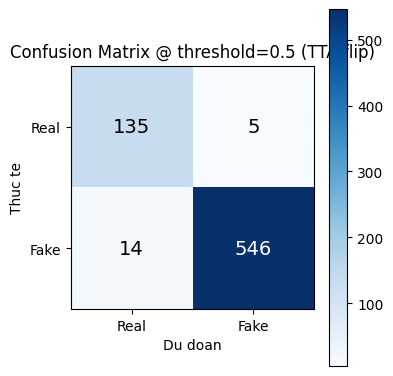

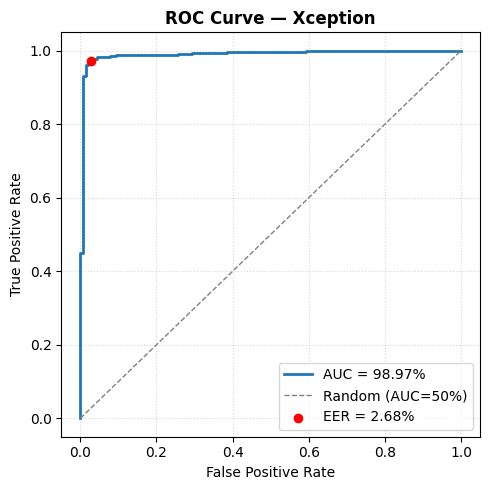

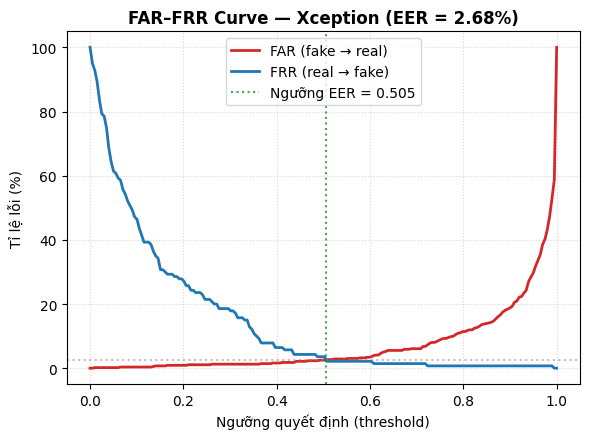


=== Breakdown theo phuong phap gia mao (test set) ===
  Deepfakes       : AUC=99.57%  EER=2.14%  (n=280)
  Face2Face       : AUC=99.46%  EER=2.14%  (n=280)
  FaceSwap        : AUC=99.14%  EER=1.43%  (n=280)
  NeuralTextures  : AUC=97.70%  EER=4.29%  (n=280)

Da luu ket qua day du vao /kaggle/working/xception_baseline/test_results_intra.csv (dung schema thong nhat 5 model)


In [8]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)  # weights_only=False can thiet tu PyTorch 2.6+
model.load_state_dict(ckpt["model_state"])
best_epoch = ckpt["epoch"]
print(f"Nap checkpoint tot nhat tu epoch {best_epoch} (phase={ckpt.get('phase','?')}, "
      f"val_acc={ckpt['val_metrics']['acc']:.4f}, val_auc={ckpt['val_metrics']['auc']:.4f})")

# SYNC (Master Prompt Phan 1 muc 2): TTA lat ngang CHI ap dung o buoc test cuoi cung nay
test_metrics = evaluate(model, test_loader, use_tta=True)
print("\n=== KET QUA TEST (intra-FF++ C23, co TTA lat ngang) -- Xception baseline ===")
print(f"Loss (BCE)          : {test_metrics['loss']:.4f}")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%  (fake bi nhan nham thanh real)")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%  (real bi nhan nham thanh fake)")
print(f"Nguong tai EER      : {test_metrics['eer_threshold']:.4f}")
print(f"FAR @ nguong EER    : {test_metrics['far_at_eer']*100:.2f}%  (~ EER theo dinh nghia)")
print(f"FRR @ nguong EER    : {test_metrics['frr_at_eer']*100:.2f}%  (~ EER theo dinh nghia)")

print("\n=== Ma tran nham lan @ threshold=0.5 ===")
cm = test_metrics["cm_at_0.5"]
print("                 Du doan Real   Du doan Fake")
print(f"Thuc te Real      {cm[0,0]:>10d}   {cm[0,1]:>12d}")
print(f"Thuc te Fake      {cm[1,0]:>10d}   {cm[1,1]:>12d}")

# ---- ve heatmap confusion matrix ----
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te")
ax.set_title("Confusion Matrix @ threshold=0.5 (TTA flip)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=100)
plt.show()

# ---- MỚI: ROC curve (trước đây không có -- đồng bộ với SBI/Wu/Spatial/rPPG/CAN) ----
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (AUC=50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]], color="red", zorder=5,
           label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Xception", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

# ---- MỚI: FAR-FRR curve (trước đây không có) ----
thr, fars, frrs = calc_far_frr_curve(test_metrics["y_true"], test_metrics["y_score"])
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.7,
           label=f"Ngưỡng EER = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Ngưỡng quyết định (threshold)"); ax.set_ylabel("Tỉ lệ lỗi (%)")
ax.set_title(f"FAR–FRR Curve — Xception (EER = {test_metrics['eer']*100:.2f}%)", fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()

# ==================== SYNC: Breakdown AUC/EER theo tung phuong phap gia mao ====================
# (Master Prompt Phan 2.1) -- dung lai chinh y_true/y_score da tinh o tren, KHONG chay lai model.
# DA SUA LOI NGHIEM TRONG: ban truoc dung lai video_id -> method qua
# `test_df.set_index("video_id")["method"].to_dict()`. Vi FF++ dung CHUNG 1 video_id (dang
# "id1_id2") cho ca 4 phuong phap fake cua cung 1 cap nguon, set_index() bi TRUNG KHOA va chi
# giu lai method cua dong CUOI CUNG xuat hien cho moi video_id (luon la NeuralTextures theo thu
# tu dong trong manifest) -> TOAN BO video fake bi gan nham method="NeuralTextures", 3 method
# con lai rong hoan toan (bang chung: chay truoc do in ra "NeuralTextures: n=700" = TOAN BO test
# set, trong khi 3 method kia bao "khong du 2 lop"). Cach sua: lay thang `methods_arr` tra ve
# TRUC TIEP tu dataset/evaluate() (da sua o Muc 3 va Muc 6), khong tra qua video_id nua.
print("\n=== Breakdown theo phuong phap gia mao (test set) ===")
y_true_arr = np.array(test_metrics["y_true"])
y_score_arr = np.array(test_metrics["y_score"])
methods_arr = np.array(test_metrics["methods"])

real_mask = (y_true_arr == 0)
breakdown = {}
for method in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    m_mask = (methods_arr == method) | real_mask
    yt_m, ys_m = y_true_arr[m_mask], y_score_arr[m_mask]
    if len(np.unique(yt_m)) < 2:
        breakdown[method] = {"auc": float("nan"), "eer": float("nan")}
        print(f"  {method:16s}: khong du 2 lop de tinh AUC/EER (bo qua)")
        continue
    b_auc = roc_auc_score(yt_m, ys_m)
    b_eer = calc_eer(yt_m, ys_m)
    breakdown[method] = {"auc": b_auc, "eer": b_eer}
    print(f"  {method:16s}: AUC={b_auc*100:.2f}%  EER={b_eer*100:.2f}%  (n={m_mask.sum()})")

# ---- gpu_hours: cong don thoi gian moi epoch da log trong luc train (khong do lai) ----
gpu_hours = sum(history["epoch_time_sec"]) / 3600.0

result_row = {
    "model": "Xception",
    "input_modality": "spatial_rgb",   # DA SUA: chuan hoa khop UCF (truoc la "spatial", cung 1 loai du lieu nhung khac nhan -> gay lech khi gop bang 5 model)
    "params_M": round(n_params / 1e6, 2),
    "epochs_planned": PHASE1_EPOCHS + PHASE2_EPOCHS,
    "epochs_run": global_epoch,
    "best_epoch": best_epoch,
    "checkpoint_criterion": "val_auc",
    "tta_used": "hflip",   # DA SUA: chuan hoa khop UCF (truoc la "flip", cung 1 ky thuat TTA nhung khac nhan)
    "gpu_hours": round(gpu_hours, 3),
    "loss_intra": test_metrics["loss"],
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "auc_Deepfakes": breakdown["Deepfakes"]["auc"], "eer_Deepfakes": breakdown["Deepfakes"]["eer"],
    "auc_Face2Face": breakdown["Face2Face"]["auc"], "eer_Face2Face": breakdown["Face2Face"]["eer"],
    "auc_FaceSwap": breakdown["FaceSwap"]["auc"], "eer_FaceSwap": breakdown["FaceSwap"]["eer"],
    "auc_NeuralTextures": breakdown["NeuralTextures"]["auc"], "eer_NeuralTextures": breakdown["NeuralTextures"]["eer"],
}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\nDa luu ket qua day du vao {OUT_DIR}/test_results_intra.csv (dung schema thong nhat 5 model)")

## 8. Vẽ đường cong huấn luyện (kiểm tra overfitting)

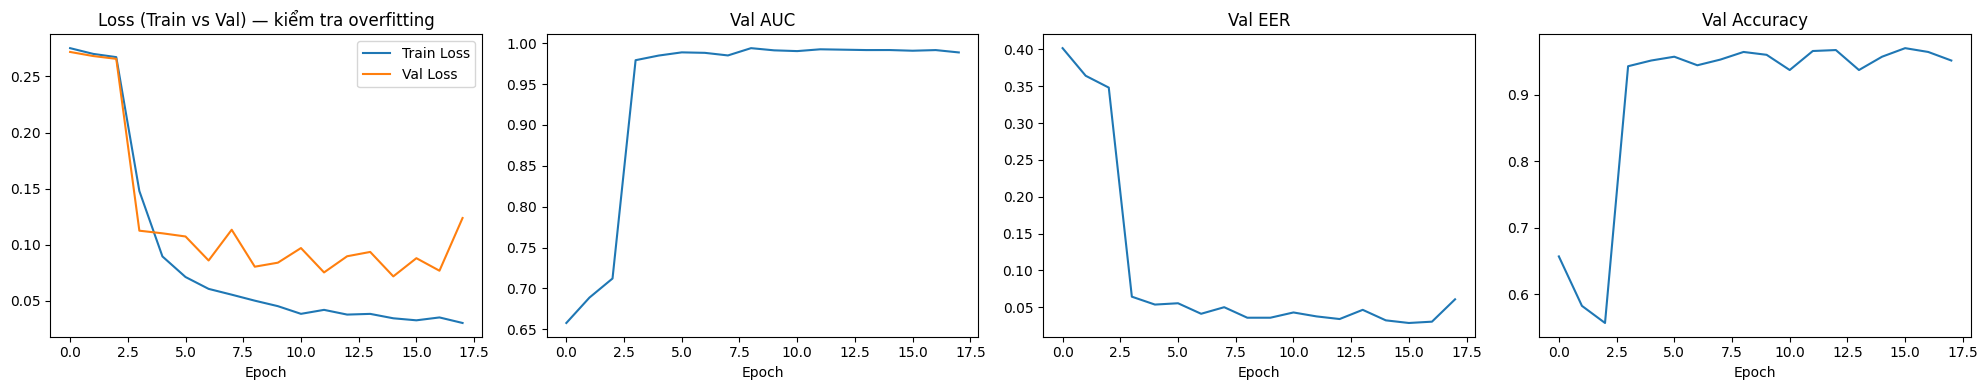

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss (Train vs Val) — kiểm tra overfitting")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["val_auc"]); axes[1].set_title("Val AUC"); axes[1].set_xlabel("Epoch")
axes[2].plot(history["val_eer"]); axes[2].set_title("Val EER"); axes[2].set_xlabel("Epoch")
axes[3].plot(history["val_acc"]); axes[3].set_title("Val Accuracy"); axes[3].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=100)
plt.show()

## 9. ⚠️ Lưu kết quả vĩnh viễn & bước tiếp theo

Làm giống hệt notebook chuẩn bị dữ liệu: **Save Version → Save & Run All (Commit)** → sau khi
chạy xong, vào tab **Output** → **New Dataset** để lưu lại:
- `xception_best.pth` (checkpoint)
- `train_history.csv`, `test_results_intra.csv`
- `training_curves.png`

**Bước tiếp theo:** dùng đúng `CACHE_DIR`, `MANIFEST_CSV`, và class `FFPPFrameTrainDataset` /
`FFPPVideoEvalDataset` / `calc_metrics()` ở notebook này làm khuôn mẫu để build lần lượt:
1. **SBI** — chỉ cần lọc `manifest[manifest.label == 0]` (video real) làm nguồn train, tự
   sinh fake bằng self-blending ngay trong `__getitem__` (không dùng video fake đã crop sẵn)
2. **UCF** — tương tự Xception nhưng thêm nhánh disentanglement (tham khảo code DeepfakeBench)
3. **Wu et al. (Spatial+rPPG)** — cần thêm bước trích tín hiệu rPPG từ ảnh đã crop (dùng biến
   thiên màu kênh xanh lá qua các frame) — phức tạp nhất, để cuối cùng
4. **Mô hình đề xuất (DeepfakeFusionModel)** — dùng `FFPPVideoEvalDataset` gần như nguyên bản
   (đã trả về đủ 32 frame/video, phù hợp cho cả nhánh Swin/ConvNeXt lẫn nhánh rPPG)

Mỗi notebook sau nên lưu `test_results_intra.csv` với cùng format cột như notebook này —
cuối cùng gộp cả 5 file này lại là ra bảng so sánh chính của khóa luận/bài báo.